# Introduction

This is an introductory Notebook for **[BirdCLEF 2026](https://www.kaggle.com/competitions/birdclef-2026)** new competition.   

### Past BirdCLEF competitions

Kaggle conducted similar competitions in past years, and those attracted a large interest from the community. Here are the links for the few of the past competitions: 

- [BirdCLEF 2021](https://www.kaggle.com/c/birdclef-2021)
- [BirdCLEF 2022](https://www.kaggle.com/c/birdclef-2022)
- [BirdCLEF 2023](https://www.kaggle.com/c/birdclef-2023)
- [BirdCLEF 2025](https://www.kaggle.com/c/birdclef-2025)

<img src="https://www.imageclef.org/system/files/bird_soundsc.jpg" width=400></img>

### Utility scripts

For clarity, functions are extracted as part of 3 utility scripts (Python modules):
* https://www.kaggle.com/code/gpreda/data-quality-stats/settings - for missing, unique, most frequent values  
* https://www.kaggle.com/code/gpreda/plot-utils - for custom count plot, wordcloud  
* https://www.kaggle.com/code/gpreda/data-quality-stats/ - for sounds play, soundwave and spectrogram  

### Content  

The Notebook is structured as following:
- <a href='#1'>Prepare analysis</a>  
  - <a href='#11'>Packages</a>  
  - <a href='#12'>Read metadata (csv) files</a>  
  - <a href='#13'>Quicly glimpse the metadata files</a>   
  - <a href='#14'>The sounds data</a>   
- <a href='#2'>Deep dive into the metadata</a>
  - <a href='#21'>Utility functions</a>  
  - <a href='#22'>Few stats</a>  
  - <a href='#24'>Names, species words distribution</a>   
- <a href='#3'>Sample sounds analysis</a>  
  - <a href='#31'>Sound utility functions</a>  
  - <a href='#32'>Test the sound utility functions</a>   
  - <a href='#33'>Check few sounds</a>  
  


# <a id='1'>Prepare analysis</a>

Here we prepare the packages used for the analysis (more in the added utility functions section) and we read the metadata files (csv files).

## <a id='11'>Packages</a>

In [1]:
import os
import sys
import numpy as np
import pandas as pd

## <a id='12'>Read metadata (csv) files</a>

In [2]:
bird_taxonomy_df = pd.read_csv("/kaggle/input/competitions/birdclef-2026/taxonomy.csv")
train_soundscapes_labels_df = pd.read_csv("/kaggle/input/competitions/birdclef-2026/train_soundscapes_labels.csv")
sample_submission_df = pd.read_csv("/kaggle/input/competitions/birdclef-2026/sample_submission.csv")

## <a id='13'>Quickly glimpse the text files</a>

In [3]:
bird_taxonomy_df.head(2)

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia


In [4]:
train_soundscapes_labels_df.head(2)

,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380


In [5]:
sample_submission_df.head(2)

,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2026_Test_0001_S05_20250227_010002_10,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274


## <a id='14'>The sounds data</a>

In [6]:
print(f"Test set: {len(os.listdir('/kaggle/input/competitions/birdclef-2026/test_soundscapes'))} folder/file")
print(f"Train set: {len(os.listdir('/kaggle/input/competitions/birdclef-2026/train_audio'))} folders")
folder_dim = [len(files) for r, d, files in os.walk('/kaggle/input/competitions/birdclef-2026/train_audio')]
files_total = sum(folder_dim)
print(f"Train set: {files_total} files")

Test set: 1 folder/file
Train set: 206 folders
Train set: 35549 files


# <a id='2'>Deep dive into the metadata</a>

## <a id='21'>Utility functions</a>

Here we include utility scripts for:
* data quality stats  
* plots utilities

The utility scripts for data quality statistics are:
- missing_data  
- unique_values  
- most_frequent_values  

The utility scripts for plots are:  
- genSankey  
- show_wordcloud  
- plot_count  


In [7]:
from data_quality_stats import missing_data, unique_values, most_frequent_values
from plot_utils import genSankey, show_wordcloud, plot_count

/opt/conda/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.9.1-CAPI-1.14.2) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


## <a id='22'>Few stats</a>

In [8]:
missing_data(bird_taxonomy_df)

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
Total,0,0,0,0,0
Percent,0.0,0.0,0.0,0.0,0.0
Types,object,int64,object,object,object


In [9]:
unique_values(bird_taxonomy_df)

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
Total,234,234,234,234,234
Uniques,234,210,234,234,5


In [10]:
most_frequent_values(bird_taxonomy_df)

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
Total,234,234,234,234,234
Most frequent item,1161364,47158,Guyalna cuta,Guyalna cuta,Aves
Frequence,1,25,1,1,162
Percent from total,0.427,10.684,0.427,0.427,69.231


In [11]:
missing_data(train_soundscapes_labels_df)

,filename,start,end,primary_label
Total,0,0,0,0
Percent,0.0,0.0,0.0,0.0
Types,object,object,object,object


In [12]:
unique_values(train_soundscapes_labels_df)

,filename,start,end,primary_label
Total,1478,1478,1478,1478
Uniques,66,12,12,251


In [13]:
most_frequent_values(train_soundscapes_labels_df)

,filename,start,end,primary_label
Total,1478,1478,1478,1478
Most frequent item,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,23158;24279;24321;517063;555146;65380;66971
Frequence,24,126,126,54
Percent from total,1.624,8.525,8.525,3.654


## <a id='24'>Names, species words distribution</a>


For scientific name, common name, class name, we present the data distribution using wordcloud.

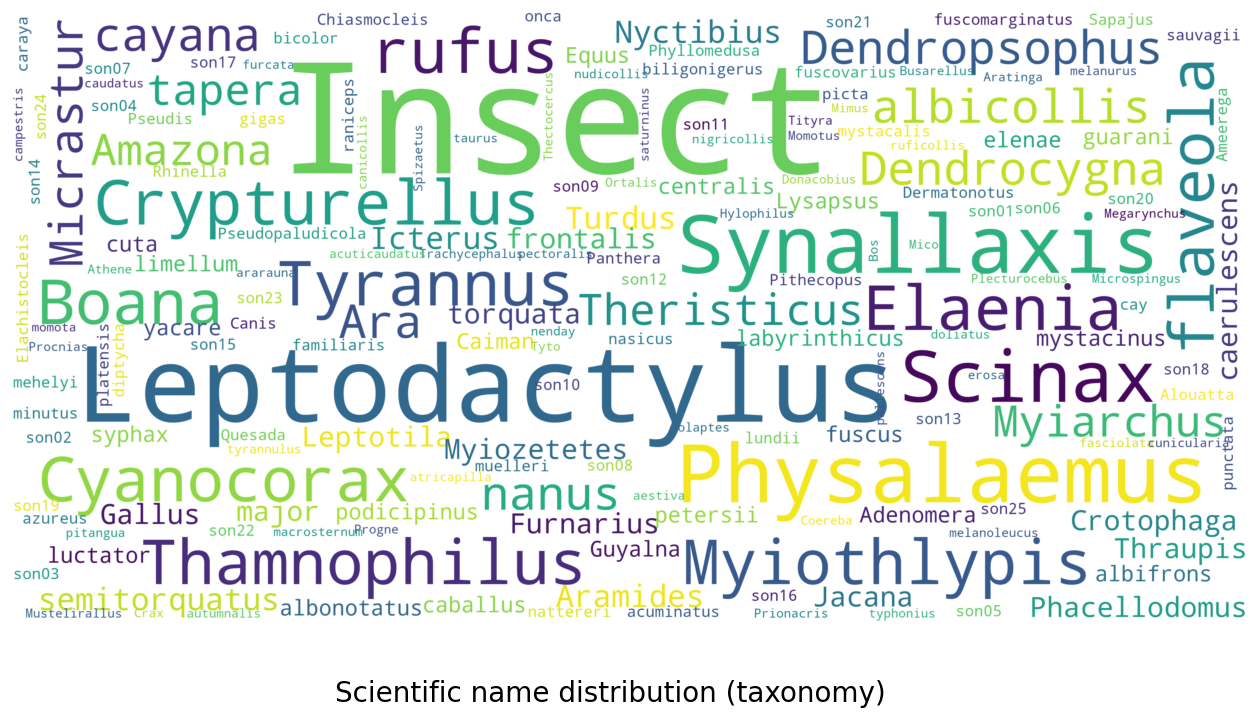

In [14]:
show_wordcloud(bird_taxonomy_df["scientific_name"], title="Scientific name distribution (taxonomy)")

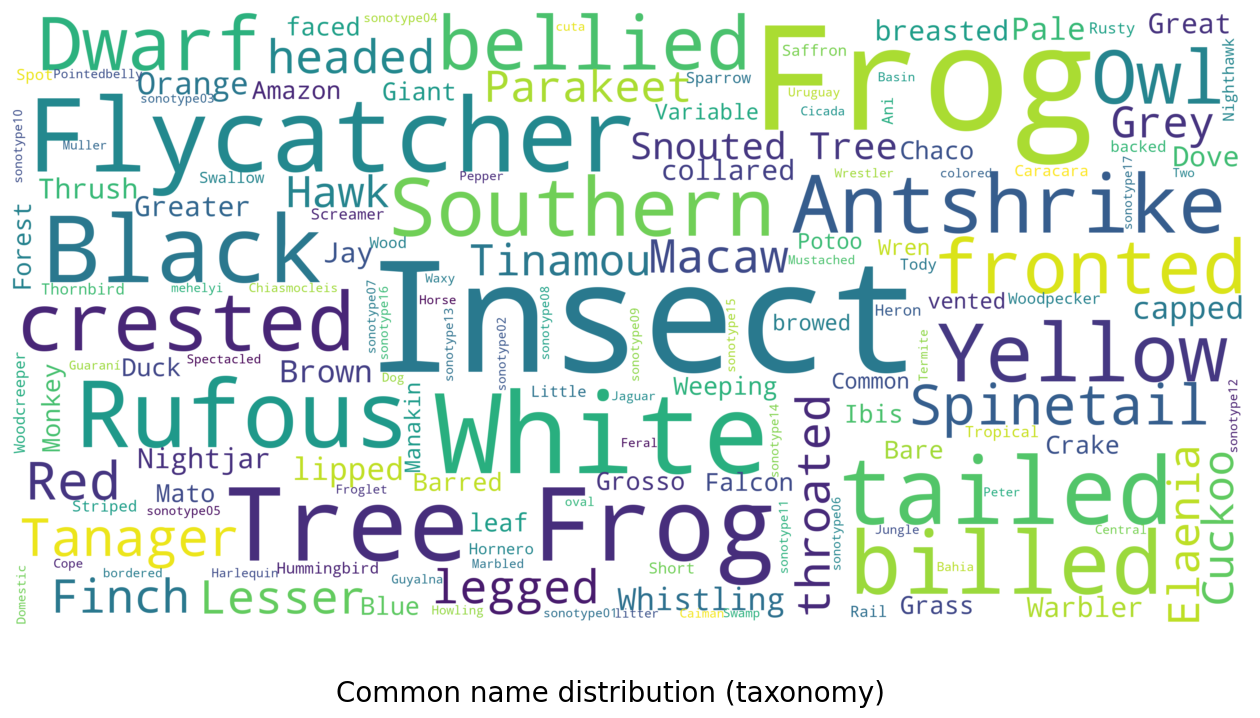

In [15]:
show_wordcloud(bird_taxonomy_df["common_name"], title="Common name distribution (taxonomy)")

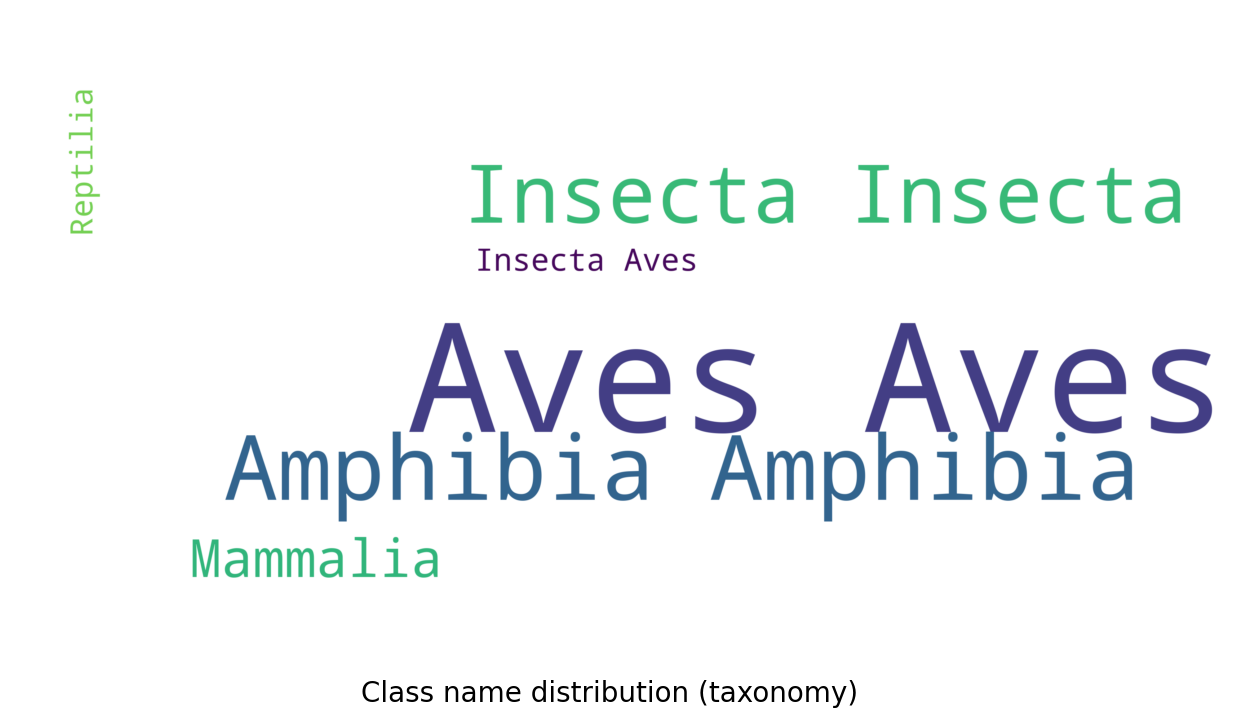

In [16]:
show_wordcloud(bird_taxonomy_df["class_name"], title="Class name distribution (taxonomy)")

# <a id='3'>Sample sounds analysis</a>

## <a id='31'>Sound utility functions</a> 


We import the utility scripts for audio data:
- play_sound  
- display_sound_wave  
- display_spectrogram  

In [17]:
from audio_plot_utils import play_sound, display_sound_wave, display_spectrogram

## <a id='32'>Test the sound utility functions</a>

In [18]:
train_path = "/kaggle/input/competitions/birdclef-2026/train_soundscapes/BC2026_Train_0001_S08_20250606_030007.ogg"
play_sound(train_path)

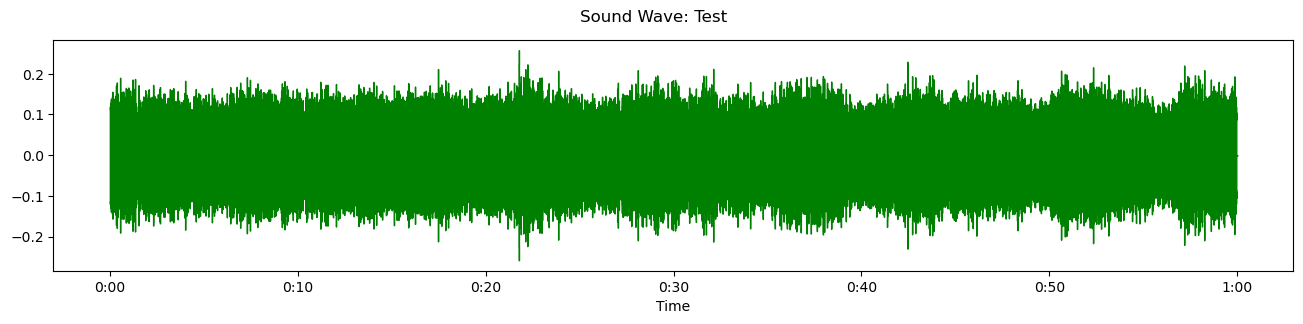

In [19]:
display_sound_wave(train_path)

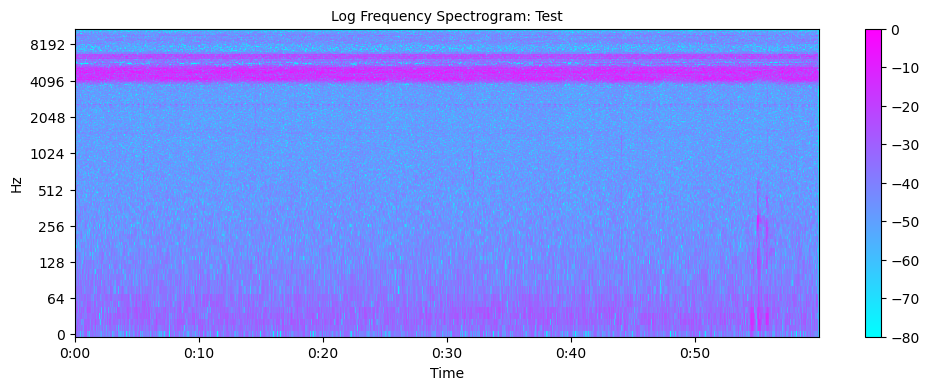

In [20]:
display_spectrogram(train_path)

## <a id='33'>Check few sounds</a>

We prepare one more utility function. This one, being specific to this Notebook/dataset, we are not extracting in a separate utility scripts.

In [21]:
def sound_utility_sample_per_primary_label(primary_label="1161364", color="red"):
    base_path = "/kaggle/input/competitions/birdclef-2026/train_audio"
    full_path = os.path.join(base_path, primary_label)
    data = os.listdir(full_path)
    print(f"Samples count {len(data)}")
    sample_path = os.path.join(full_path, data[0])
    text = f"{primary_label} (sample)"
    play_sound(sample_path, text=text, color=color)
    display_sound_wave(sample_path, text=text, color=color)
    display_spectrogram(sample_path, text=text)

### Test

Let's test this utility function.

Samples count 11


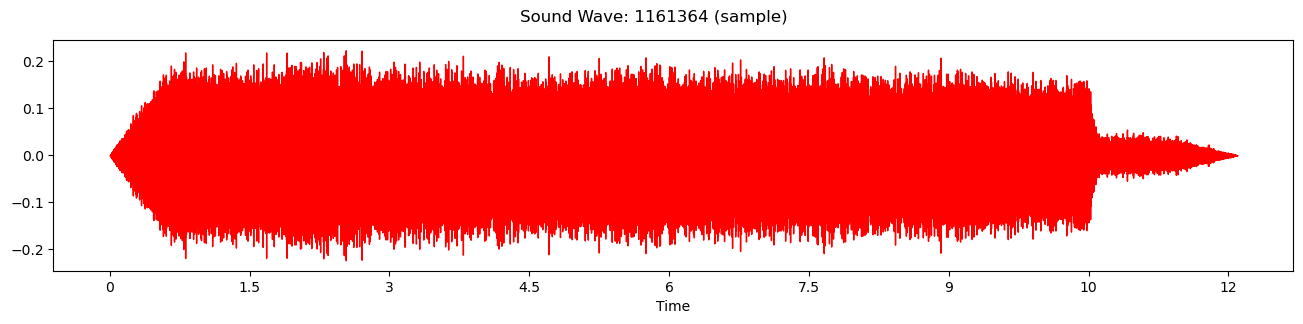

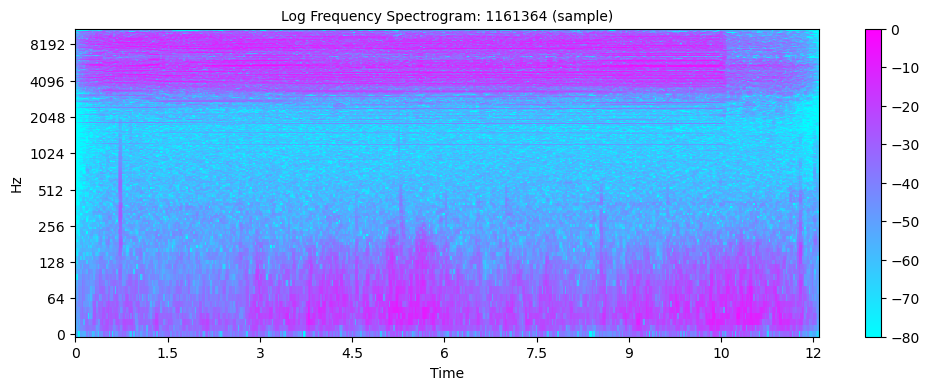

In [22]:
sound_utility_sample_per_primary_label()

### Few bird songs samples from the train set

Here we present few bird songs samples from the train set.
We pass as parameter the `primary_label` and we sample one case from the set and then call the functions to play the sound, present the spectrogram and the Mel spectrogram.

Samples count 2


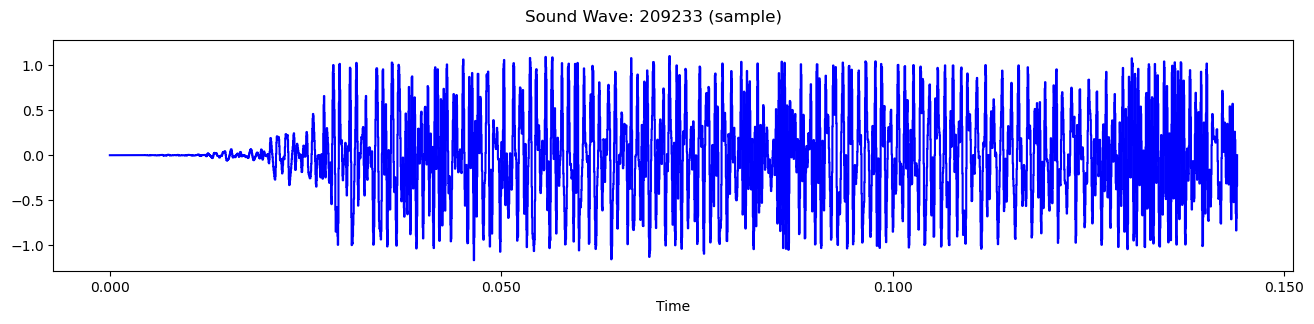

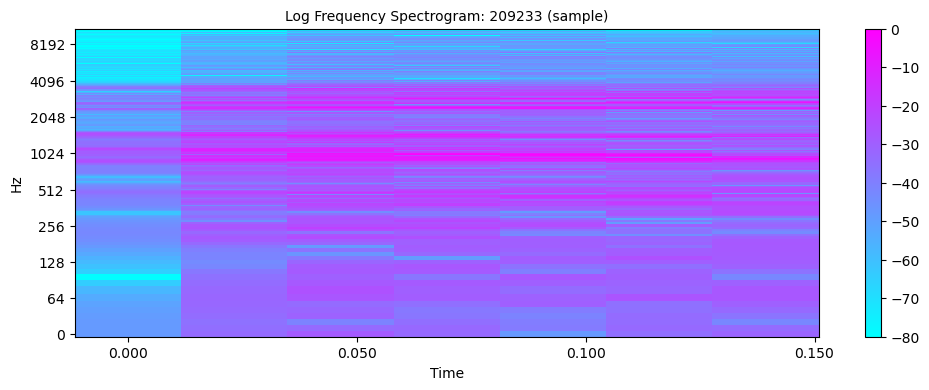

In [23]:
sound_utility_sample_per_primary_label('209233', color='blue')

Samples count 5


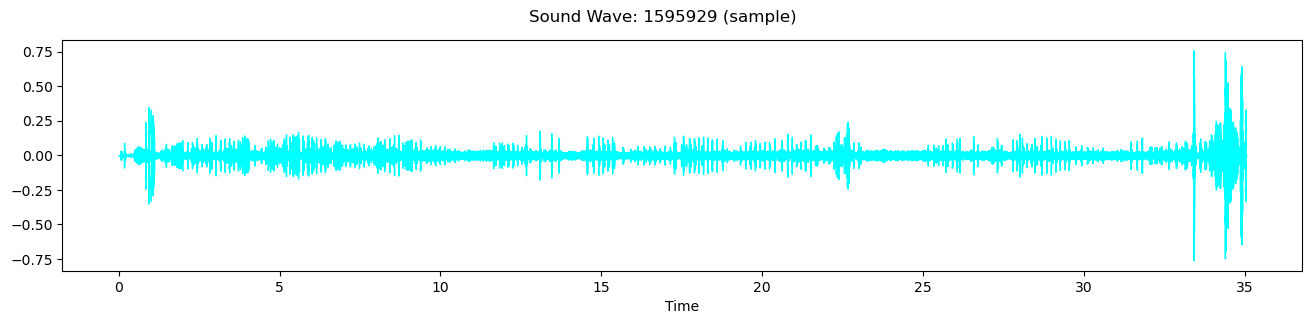

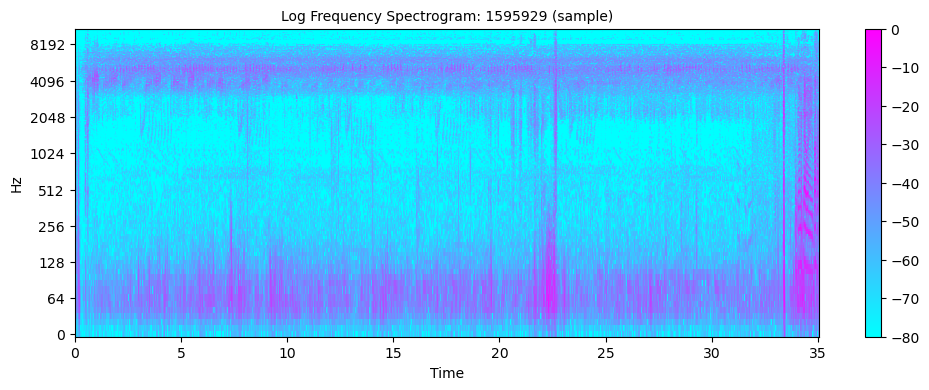

In [24]:
sound_utility_sample_per_primary_label('1595929', color='cyan')

Samples count 6


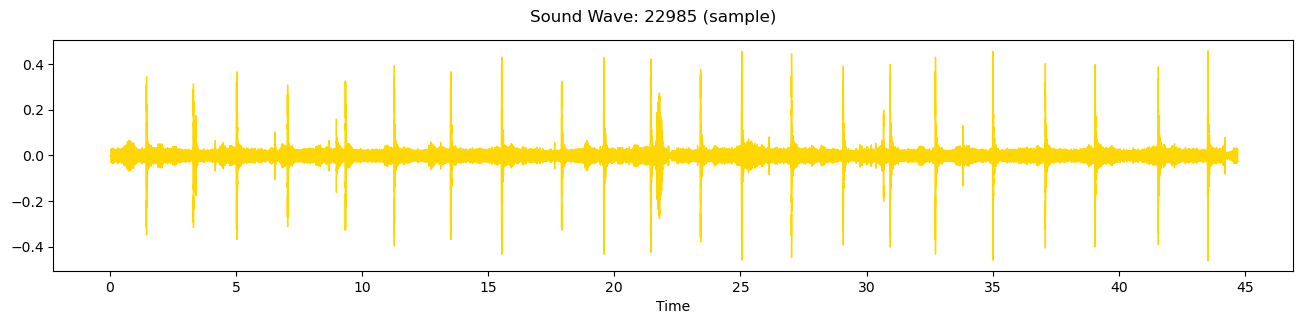

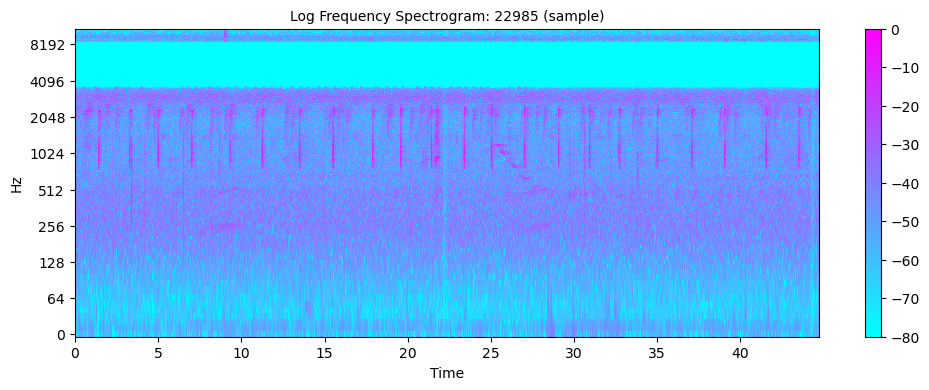

In [25]:
sound_utility_sample_per_primary_label('22985', color='gold')

Samples count 46


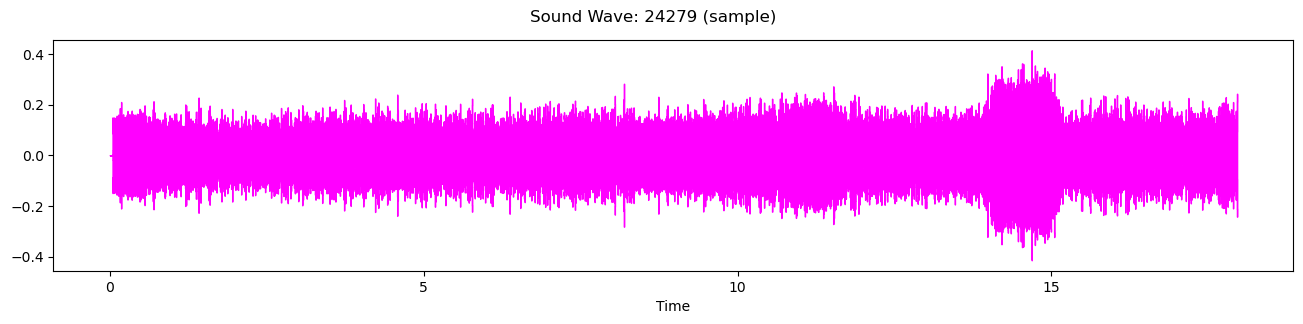

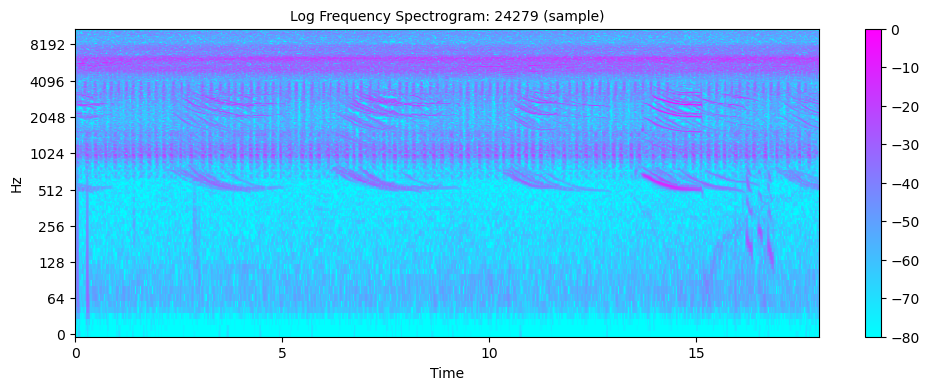

In [26]:
sound_utility_sample_per_primary_label('24279', color='magenta')

Samples count 3


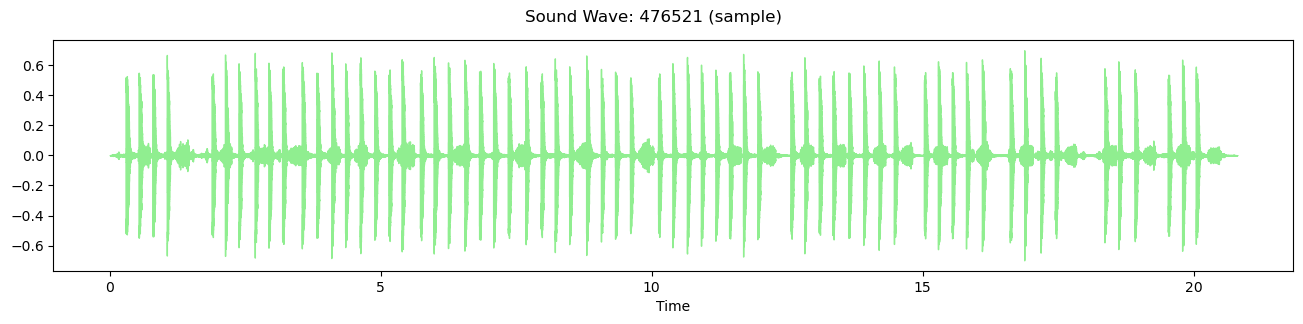

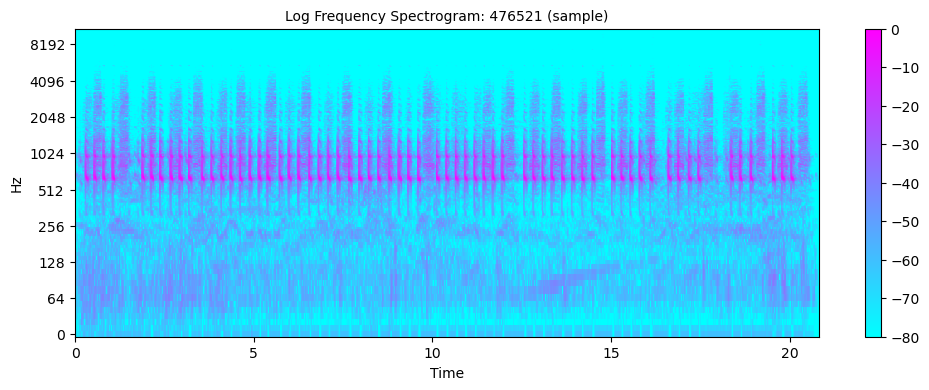

In [27]:
sound_utility_sample_per_primary_label('476521', color='lightgreen')

Samples count 1


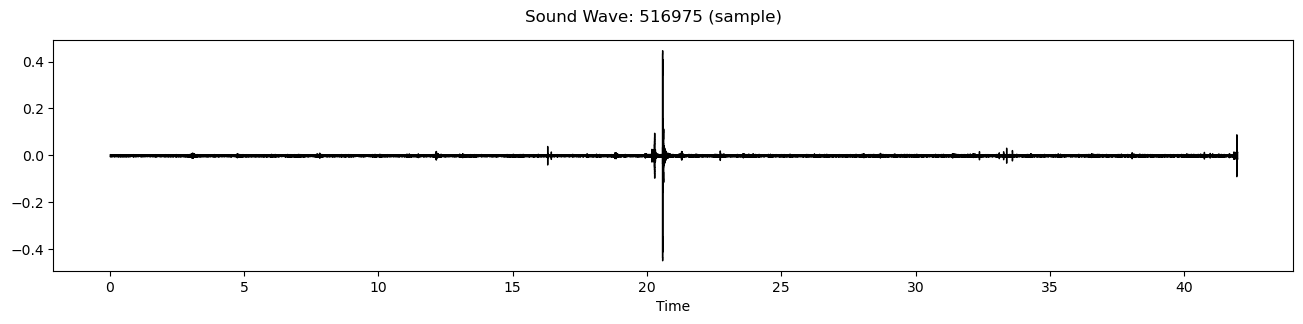

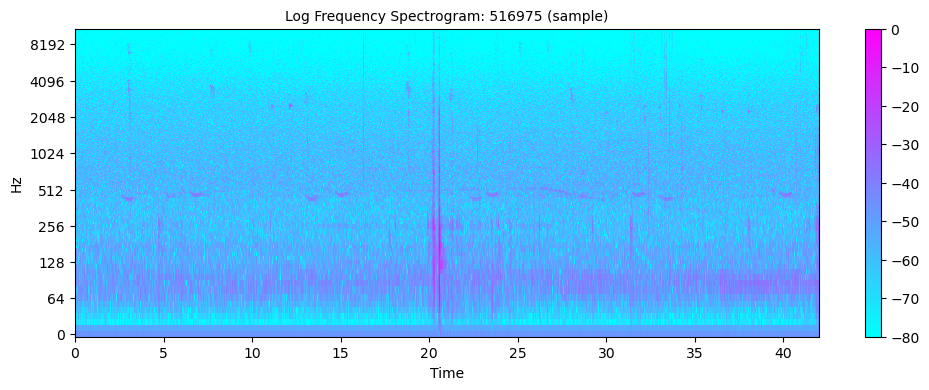

In [28]:
sound_utility_sample_per_primary_label('516975', color='black')

Samples count 63


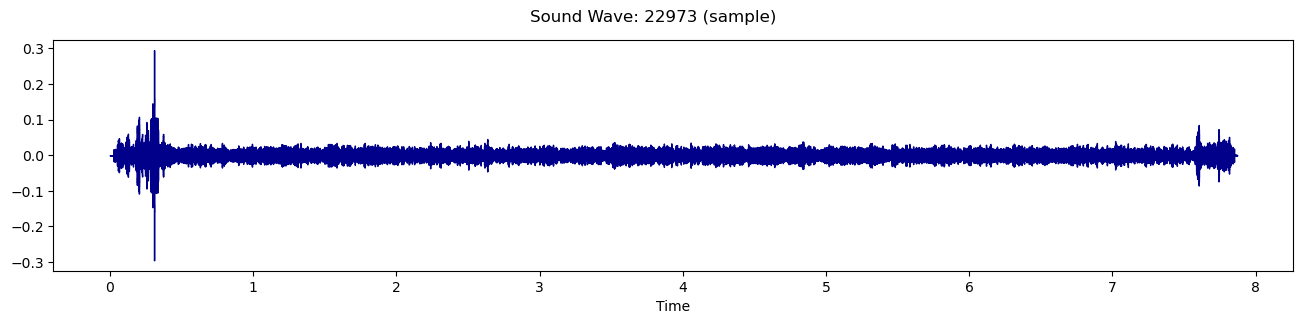

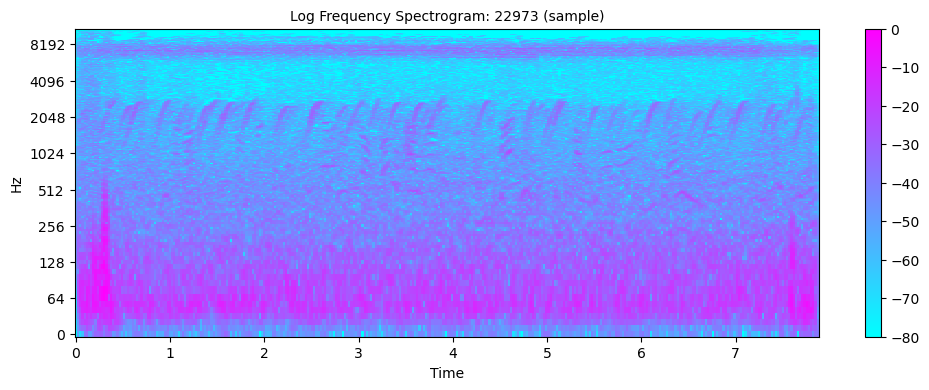

In [29]:
sound_utility_sample_per_primary_label('22973', color='darkblue')

# What's next?

Deep dive the analysis in image modality.

Prepare a training/validation set (from sounds -> images) and solve the problem in image modality (vs. in sounds).
